<a href="https://colab.research.google.com/github/spokenprim618/cmp-415/blob/main/Copy_of_MidtermProject_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Midterm Project Part 1
# Analyzing the Demand for Bike Sharing

Bike sharing systems are a means of renting bicycles where the process of obtaining membership, rental, and bike return is automated via a network of kiosk locations throughout a city. Using these systems, people are able rent a bike from a one location and return it to a different place on an as-needed basis. Currently, there are over 500 bike-sharing programs around the world.

For this project, we will explore a dataset from Capital Bikeshare, a bike-sharing program in Washington, D.C. It is interesting to discover bike usage patterns with weather condition and the nature of the day.

# I. Acquire the Dataset

1. Download the data `Bike-Sharing-Dataset.zip` file from [Bike Sharing dataset in the Machine Learning Repository at UC Irvine](https://archive-beta.ics.uci.edu/dataset/275/bike+sharing+dataset). Unzip the file and obtain file `day.csv`. Read the description of the dataset to learn the meaning of values in each column.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import requests
from zipfile import ZipFile


2. Load the data from `day.csv` as a Pandas data frame. Display its first 5 rows to confirm that the data is loaded correctly.

In [ ]:

os.makedirs("data", exist_ok=True)
print("Folder 'data' is ready!")


url = "https://cdn.uci-ics-mlr-prod.aws.uci.edu/275/bike%2Bsharing%2Bdataset.zip"

zip_path = "data/Bike-Sharing-Dataset.zip"

r = requests.get(url)
with open(zip_path, "wb") as f:
    f.write(r.content)

print("Downloaded the dataset!")

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files extracted:", os.listdir("data"))

data = pd.read_csv('/content/data/day.csv')
data_copy = data.copy()

data_copy.head()

Folder 'data' is ready!
Downloaded the dataset!
Files extracted: ['cleaned_data.csv', 'Bike-Sharing-Dataset.zip', 'hour.csv', 'day.csv', 'Readme.txt']


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


3. Display the shape of the data frame.

In [ ]:
data_copy.shape

(731, 16)

4. Display the data type of each column

In [ ]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


5. The default data type for 'dteday' is `object`. Use [pd.to_datetime](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) to convert it to `datetime` type. After the conversion, display the data types again to confirm that the conversion is successful.

In [ ]:
data_copy['dteday']=pd.to_datetime(data_copy['dteday'])
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

6. Create a new column 'year' by extracting the year value from the datetime of each row.

In [ ]:
data_copy['year'] = data_copy['dteday'].dt.year

7. Remove the "casual" column and the "registered" column, as we are solely interested in the total number of bike rentals, which is given in the "cnt" column. Also remove the following columns: 'instant', 'yr', 'atemp'. Display the first 5 rows again to confirm the removal of these columns.

> Add blockquote



In [ ]:
data_copy.drop(['casual','registered','instant', 'yr', 'atemp'], axis=1,inplace=True)

data_copy.head()


,dteday,season,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,year
0,2011-01-01,1,1,0,6,0,2,0.344167,0.805833,0.160446,985,2011
1,2011-01-02,1,1,0,0,0,2,0.363478,0.696087,0.248539,801,2011
2,2011-01-03,1,1,0,1,1,1,0.196364,0.437273,0.248309,1349,2011
3,2011-01-04,1,1,0,2,1,1,0.200000,0.590435,0.160296,1562,2011
4,2011-01-05,1,1,0,3,1,1,0.226957,0.436957,0.186900,1600,2011


8. Display the number of missing values from each column.

In [ ]:
data_copy.isna().sum()

,0
dteday,0
season,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0
hum,0
windspeed,0


## II. Data Exploration

1. The season feature: split the data frame into four subsets according to the season value. You may call them `data_spring`, `data_summer`, `data_fall`, `data_winter`. Calculate and display the average bike rentals in each season.

In [ ]:
#	- season : season (1:springer, 2:summer, 3:fall, 4:winter)

data_spring = data_copy[data_copy['season']==1]
data_summer = data_copy[data_copy['season']==2]
data_fall = data_copy[data_copy['season']==3]
data_winter = data_copy[data_copy['season']==4]

season_means=[]
data_spring_rental_average= data_spring['cnt'].mean()
data_summer_rental_average= data_summer['cnt'].mean()
data_fall_rental_average= data_fall['cnt'].mean()
data_winter_rental_average= data_winter['cnt'].mean()
season_means.append(data_spring_rental_average)
season_means.append(data_summer_rental_average)
season_means.append(data_fall_rental_average)
season_means.append(data_winter_rental_average)
print(season_means)



[np.float64(2604.1325966850827), np.float64(4992.33152173913), np.float64(5644.303191489362), np.float64(4728.162921348315)]


2. The 'holiday' feature: calculate and display the average bike rentals for holidays and non-holidays, separately.

In [ ]:
data_holiday=data_copy[data_copy['holiday']==1]
data_not_holiday=data_copy[data_copy['holiday']==0]

holdiay_means=[]
data_holiday_mean=data_holiday['cnt'].mean()
data_not_holiday_mean=data_not_holiday['cnt'].mean()

holdiay_means.append(data_holiday_mean)
holdiay_means.append(data_not_holiday_mean)
print(holdiay_means)

[np.float64(3735.0), np.float64(4527.104225352113)]


3. The 'workingday' feature: calculate and display the average bike rentals for working days and weekends, separately.

In [ ]:
data_working = data_copy[data_copy['workingday'] == 1]
data_weekend = data_copy[data_copy['workingday'] == 0]

workingday_avg = data_working['cnt'].mean()
weekend_avg = data_weekend['cnt'].mean()

workingday_means= []

workingday_means.append(workingday_avg)
workingday_means.append(weekend_avg)

print(workingday_means)

[np.float64(4584.82), np.float64(4330.168831168831)]


4. The 'weathersit' feature: calculate and display the average bike-rentals for each weather type.

In [ ]:
#	- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
#		- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
#		- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
#		- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

print(data_copy['weathersit'].unique())

data_weather1 = data_copy[data_copy['weathersit'] == 1]
data_weather2 = data_copy[data_copy['weathersit'] == 2]
data_weather3 = data_copy[data_copy['weathersit'] == 3]

weather1_avg = data_weather1['cnt'].mean()
weather2_avg = data_weather2['cnt'].mean()
weather3_avg = data_weather3['cnt'].mean()

weather_means = [weather1_avg, weather2_avg, weather3_avg]

print(weather_means)

[2 1 3]
[np.float64(4876.7861771058315), np.float64(4035.862348178138), np.float64(1803.2857142857142)]


5. The 'temp' feature: as temperature is a countinous feature, its relationship with the 'count' feature can be visualized as a scatter plot. Create a scatter plot with 'temp' and 'count'. Label the axis correctly.

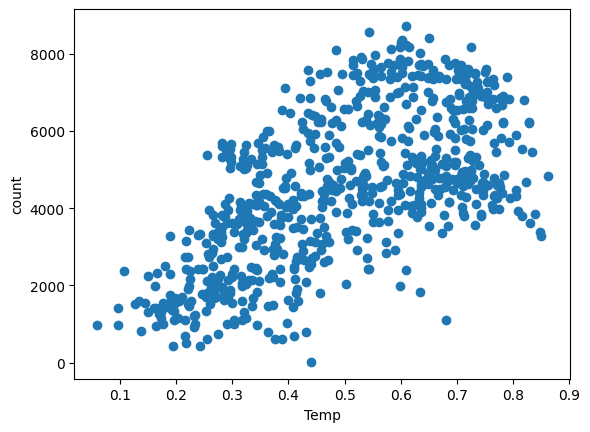

In [ ]:
plt.scatter(data_copy['temp'],data_copy['cnt'])
plt.xlabel("Temp")
plt.ylabel("count")
plt.show()

6. The 'windspeed' feature: create a scatter plot to show the relatioinship between the number of bike rentals and the windspeed.

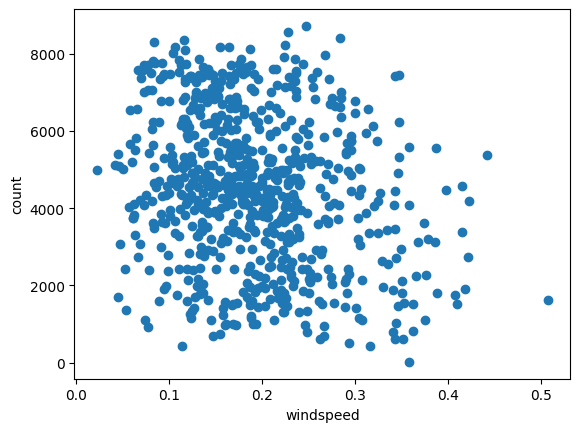

In [ ]:
plt.scatter(data_copy['windspeed'],data_copy['cnt'])
plt.xlabel("windspeed")
plt.ylabel("count")
plt.show()

7. The 'year' feature: calculate and display the average bike rentals in each year.

In [ ]:
data_copy['year'].unique()

data_2011 =data_copy[data_copy['year']==2011]
data_2012 =data_copy[data_copy['year']==2012]

year_means =[]

mean_2011 = data_2011['cnt'].mean()
mean_2012 = data_2012['cnt'].mean()

year_means.append(mean_2011)
year_means.append(mean_2012)
print(year_means)

[np.float64(3405.7616438356163), np.float64(5599.934426229508)]


8. What observations can you conclude from the data exploration?

**Answer:**
I noticed within the seasons the 1st is fall, 2nd summer, 3rd winter, 4th spring.

Less people bike on holidays.

More people bike on workdays.

The better the weather more people bike and the 4th type of weather is missing from the data.

Temperature and the count of bikes relationship is linear with high amounts of spread but generally follow an upward trend.

Wind speed and count of bikes has no linear relationship. There is no cleear upward or downward trend spread is random.

More people biked in 2012 than 2011.

I can conclude the higher the temperture the more people will bike but as shown through the averages of the seasons people will still bike during fall and winter. Fall being higher than summer should be explored more. Spring being significantly lower than the rest is strange and should be explored more especially compared to winter. The higher severity weather storms have the greatest impact on rider counts. Working day or not doesnt make a significant difference in riders. The change of riders from 2011 to 2012 should be explored more due to such a high increase in a year. There should be more exploration on who make up these numbers to get a better idea of usage patterns with weather condition and the nature of the day.


9. Save the final data frame as a csv file using the `to_csv()` method. Read the [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) of this method for more information.

In [ ]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      731 non-null    datetime64[ns]
 1   season      731 non-null    int64         
 2   mnth        731 non-null    int64         
 3   holiday     731 non-null    int64         
 4   weekday     731 non-null    int64         
 5   workingday  731 non-null    int64         
 6   weathersit  731 non-null    int64         
 7   temp        731 non-null    float64       
 8   hum         731 non-null    float64       
 9   windspeed   731 non-null    float64       
 10  cnt         731 non-null    int64         
 11  year        731 non-null    int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(7)
memory usage: 65.8 KB


In [ ]:
data_copy.to_csv('/content/data/cleaned_data.csv')